In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os


In [2]:
os.chdir('..')

In [3]:
STOCK = 'ETH'
TF = '1h'
LEVEL = 2
PRICE = 'close'
SEQ_LENGTH = 48
SEQ_LENGTH_MACD = 28
BATCH_SIZE = 8
TRAIN_SPLIT = 0.7
VAL_SPLIT = 0.1
TEST_SPLIT = 1 - (TRAIN_SPLIT+VAL_SPLIT)
DATA_TYPE = 'float32'
FILE_NAME = f'cnn/{STOCK}_{TF}/figs'

In [4]:
from utils.utils import CreateTimeFrames

In [5]:
df = pd.read_csv(f'data/{STOCK}USD_2023_2024.csv',
                  index_col = 'Gmt time')
df.index = pd.to_datetime(df.index, format='%d.%m.%Y %H:%M:%S.%f', errors='coerce')
df = df.rename(columns={'Date':'time', 'Open': 'open', 'High': 'high', 'Low': 'low', 'Close':'close', 'Volume':'volume'})


timeframes = [TF]
# timeframes = ['1min','5min','15min', '30min','1h', '4h','1d','1w','1m']
df = CreateTimeFrames(df,timeframes)
df_tf = df[TF]
df_tf = df_tf.iloc[-4050:,:]

# Backtester

In [6]:
os.getcwd()
# from utils.backtester import MACDBacktester

# Market strategy pattern

In [7]:
df_all = pd.read_csv(f'strategy/files/df_all_{STOCK}_{TF}.csv')

In [80]:
import numpy as np
import pandas as pd

class MACDBacktester:
    def __init__(self, data : pd.DataFrame , price : str ='close', sell_fee : np.float16 = 0.115,
                  buy_fee : np.float16 = 0.115, initial_capital : np.float32 = 100):
        """
        It works as a trade analyzer with a specific amount of money and trading cost.

        :param data: DataFrame containing different features ('macd_line', 'signal_line', price = 'close', 'y_xlstm').
        :param price: For trading (default: 'close').
        :param sell_fee: Sell trading cost in percentage (default: 0.115).
        :param buy_fee: Buy trading cost in percentage (default: 0.115).
        :param initial_capital: Initial capital.
        """
        self.data = data.copy()
        self.real_price = price
        self.sell_fee_percent = sell_fee / 100
        self.buy_fee_percent = buy_fee / 100
        self.initial_capital = initial_capital
        self.trades = []
        self.data['positions'] = 0

    def generate_signals(self):
        """
        Generates trading signals based on the MACD-XLSTM strategy.
        
        Buy signal (1) is generated when:
          - The 'macd_line' crosses above 'signal_line' (i.e. today's MACD > Signal and yesterday’s MACD ≤ Signal)
          - AND the XLSTM forecast is above the current close (y_xlstm > close)
        
        Sell signal (-1) is generated when:
          - The 'macd_line' crosses below 'signal_line' (i.e. today's MACD < Signal and yesterday’s MACD ≥ Signal)
          - AND the XLSTM forecast is below the current close (y_xlstm < close)
        
        After generating the raw signals, the method adjusts to ensure:
          - The first trade is not a sell.
          - If the final signal is a buy, it forces a sell at the end.
        
        Finally, it converts these raw signals into a binary positions indicator (1 for holding, 0 for not).
        """
        # Define buy and sell conditions
        buy_signals = (self.data['macd_line'] > self.data['signal_line']) & \
                      (self.data['macd_line'].shift(1) <= self.data['signal_line'].shift(1)) #& \
          #            (self.data['y_xlstm'] > self.data['close'])
        sell_signals = (self.data['macd_line'] < self.data['signal_line']) & \
                       (self.data['macd_line'].shift(1) >= self.data['signal_line'].shift(1)) #& \
           #            (self.data['y_xlstm'] < self.data['close'])
        
        # Initialize raw signals array: 1 for Buy, -1 for Sell, 0 for no action.
        raw_signals = np.zeros(len(self.data), dtype=np.int8)
        holding_position = False

        # Loop through each row to set signals based on the conditions and current holding state.
        for i in range(0,len(self.data)-1):   ## I took a change here.
            if buy_signals.iloc[i] and not holding_position: 
                raw_signals[i+1] = 1   ## I took a change here.
                holding_position = True
            elif sell_signals.iloc[i] and holding_position:
                raw_signals[i+1] = -1     ## A change here.
                holding_position = False
        

        # Adjust the signals:
        # 1. If the first nonzero signal is a sell, remove it.
        trade_idx = np.where(raw_signals != 0)[0]
        if len(trade_idx) > 0 and raw_signals[trade_idx[0]] == -1:
            raw_signals[trade_idx[0]] = 0

        # 2. If the last signal is a buy, force a sell at the end.
        if len(trade_idx) > 0 and raw_signals[trade_idx[-1]] == 1:
            raw_signals[-1] = -1

        # Save the raw signals in a dedicated column.
        self.data['signals_macd_xlstm'] = raw_signals

        # Convert raw signals to binary positions: 1 if in position, 0 if not.
        positions = np.zeros(len(self.data), dtype=np.int8)
        current_position = 0
        for i, signal in enumerate(raw_signals):
            if signal == 1:
                current_position = 1
            elif signal == -1:
                current_position = 0
            positions[i] = current_position
        self.data['positions'] = positions

        return self.data
    def backtest_strategy(self):
        """
        
        """
        self.data['price'] = self.data[self.real_price]
        # self.data['positions'] = self.data['positions'].astype(int)
        self.data['positions_diff'] = self.data['positions'].diff().fillna(0)
        # self.data['positions_diff'].fillna(0)

        # Initialize cash and holdings
        self.data['cash'] = self.initial_capital
        self.data['holdings'] = 0.0
        self.data['total'] = self.initial_capital

        cash = self.initial_capital
        holdings = 0.0
        position = 0  # number of shares held
        buy_price = 0.0
        win_count = 0  
        total_trades = 0

        for idx, row in self.data.iterrows():
            position_change = row['positions_diff']
            price = row['price']
            if position_change == 1:  # Enter long position
                shares_to_buy = round(cash / price, 8)
                shares_to_buy *= (1 - self.buy_fee_percent)

                if shares_to_buy > 0.00002:
                    buy_price = round(cash / shares_to_buy, 8)
                    total_cost = round(shares_to_buy * buy_price, 8)
                    cash -= total_cost
                    holdings += shares_to_buy * price
                    position += shares_to_buy

            elif position_change == -1 and position > 0:  # Exit long position
                sell_price = price * (1 - self.sell_fee_percent)
                total_proceeds = position * sell_price
                cash += total_proceeds
                holdings -= position * sell_price
                trade_return = (sell_price - buy_price) / buy_price * 100
                self.trades.append(trade_return)
                position = 0
                total_trades += 1
                if trade_return > 0:
                    win_count += 1
            else:
                holdings = position * price

            total = cash + holdings
            self.data.at[idx, 'cash'] = float(cash)
            self.data.at[idx, 'holdings'] = holdings
            self.data.at[idx, 'total'] = float(total)

        if position > 0:
            price = self.data.iloc[-1]['price']
            sell_price = price * (1 - self.sell_fee_percent)
            total_proceeds = position * sell_price
            cash += total_proceeds
            trade_return = (sell_price - buy_price) / buy_price * 100
            self.trades.append(trade_return)
            position = 0
            total_trades += 1
            if trade_return > 0:
                win_count += 1
            total = cash + holdings
            self.data.at[self.data.index[-1], 'cash'] = cash
            self.data.at[self.data.index[-1], 'holdings'] = holdings
            self.data.at[self.data.index[-1], 'total'] = total

        self.results = self.data[['cash', 'holdings', 'total']]
        self.win_rate = (win_count / total_trades * 100) if total_trades > 0 else 0
        return self.data

    def get_performance_metrics(self):
        """
        Calculates and returns performance metrics.
        (Implementation remains unchanged.)
        """
        if not hasattr(self, 'results'):
            print("Please run backtest_strategy() before calculating performance metrics.")
            return None

        total_return = (self.results['total'].iloc[-1] - self.initial_capital) / self.initial_capital * 100
        returns = self.results['total'].pct_change().fillna(0)
        annualized_return = ((1 + returns.mean()) ** 365 - 1) * 100  # Assuming daily returns
        annualized_volatility = returns.std() * np.sqrt(365) * 100

        periods_per_year = 8760
        annual_rf_rate = 0.04  
        daily_rf_rate = annual_rf_rate / 365  
        hourly_rf_rate = daily_rf_rate / 24  

        excess_returns = returns - hourly_rf_rate
        mean_hourly_excess = excess_returns.mean()
        std_hourly = returns.std()  
        sharpe_ratio = (mean_hourly_excess / std_hourly) * np.sqrt(periods_per_year) if std_hourly != 0 else np.nan

        target_return = hourly_rf_rate  
        downside_returns = returns.copy()
        downside_returns[downside_returns > target_return] = 0
        std_downside = downside_returns.std()
        annualized_downside_deviation = std_downside * np.sqrt(periods_per_year)
        annualized_excess_return = mean_hourly_excess * periods_per_year
        sortino_ratio = annualized_excess_return / annualized_downside_deviation if annualized_downside_deviation != 0 else np.nan

        max_drawdown = ((self.results['total'].cummax() - self.results['total']) / self.results['total'].cummax()).max() * 100

        metrics = {
            'Total Return (%)': total_return,
            'Annualized Return (%)': annualized_return,
            'Annualized Volatility (%)': annualized_volatility,
            'Sharpe Ratio': sharpe_ratio,
            'Sortino Ratio': sortino_ratio,
            'Max Drawdown (%)': max_drawdown,
            'Win Rate (%)': self.win_rate
        }
        return metrics, self.results

    def print_trades(self):
        """
        Prints individual trade returns.
        """
        if not self.trades:
            print("No trades have been executed.")
            return
        for idx, trade_return in enumerate(self.trades, 1):
            print(f"Trade {idx}: Return = {trade_return:.2f}%")
        total_return = sum(self.trades)
        print(f"Total Return from trades: {total_return:.2f}%")


In [74]:
# backtester = MACDBacktester(df_test, best_params.get('Fast EMA'), best_params.get('Slow EMA'), best_params.get('Signal Line'),signal_price=signal_price, real_price=real_price)
# backtester = MACDBacktester(df_test, best_params.get('Fast EMA'), best_params.get('Slow EMA'), best_params.get('Signal Line'),signal_price=signal_price, real_price=real_price)
# backtester = MACDBacktester(df_test, best_params.get('Fast EMA'), best_params.get('Slow EMA'), best_params.get('Signal Line'),signal_price=signal_price, real_price=real_price)
backtester = MACDBacktester(df_all.iloc[-805:,:], signal_price='close', real_price='close',initial_capital=df_all['close'][0])
data_with_signals =  backtester.generate_signals()
# backtester.backtest_strategy()
# metrics, results = backtester.get_performance_metrics()
# print(metrics)
# backtester.print_trades()

In [79]:
data_with_signals

,open,high,low,close,volume,smoothed_data,macd_line,signal_line,histo,y_xlstm,positions,signals_macd_xlstm
0,2366,2368,2346,2350,1.307340e+06,2343.594305,-14.896638,-14.546104,-0.350534,2353.721436,0,0
1,2350,2355,2335,2350,2.121120e+06,2342.461863,-8.643697,-9.486530,0.842832,2339.731445,1,1
2,2350,2355,2323,2345,2.970158e+06,2340.509076,-3.846501,-4.407062,0.560560,2326.243164,1,0
3,2345,2364,2313,2315,3.457770e+06,2337.301636,-2.691171,-2.691171,0.000000,2344.220947,1,0
4,2315,2344,2308,2338,3.007800e+06,2335.752988,-13.881672,-14.845504,0.963832,2342.304199,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
800,2451,2453,2400,2406,1.688868e+06,2434.422183,-6.030204,-2.907903,-3.122301,2409.425049,0,0
801,2407,2435,2401,2425,2.664360e+06,2423.347752,-14.317152,-10.473760,-3.843392,2424.525879,0,0
802,2425,2428,2411,2414,1.534140e+06,2417.403590,-17.064605,-14.690277,-2.374328,2431.579346,0,0
803,2411,2434,2405,2433,7.058580e+05,2417.281278,-14.546703,-13.167720,-1.378982,2379.471436,0,0


In [60]:
results.iloc[282:293,:]

,cash,holdings,total
282,2818.419941,0.000000,2818.419941
283,3.241183,2815.178758,2818.419941
284,3.241183,2822.737734,2825.978917
285,3.241183,2823.817588,2827.058771
286,3.241183,2816.258611,2819.499794
287,3.241183,2819.498173,2822.739356
288,2790.374411,0.000000,2790.374411
289,2790.374411,0.000000,2790.374411
290,3.208931,2787.165480,2790.374411
291,2679.732713,0.000000,2679.732713


In [67]:
tot = results['total'].diff()
tot_cum = tot.cumsum()

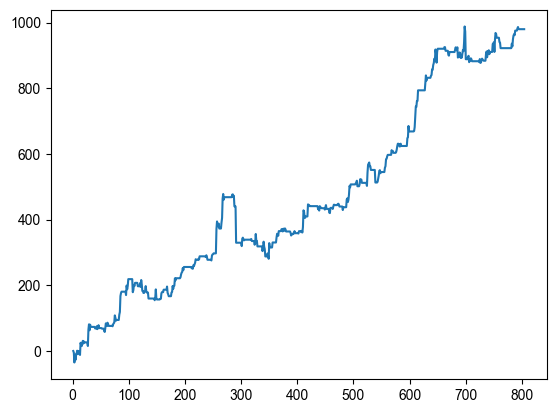

In [68]:
plt.plot(tot_cum)

# Market Strategy

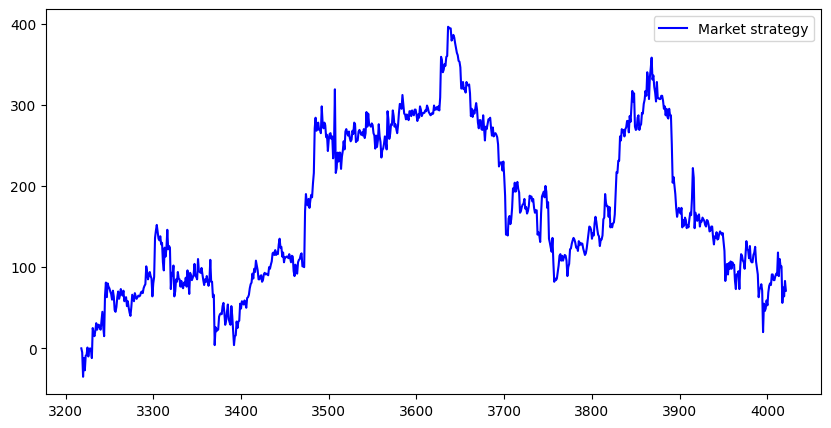

In [12]:
trade_df = pd.DataFrame({'close':df_all['close'], 'open':df_all['open']})
trade_df = trade_df.astype({
    'close': np.int32,
    'open': np.int32
})

trade_df = trade_df.iloc[-805:,:]

trade_df['tomorrows_returns'] = 0
trade_df['tomorrows_returns'] = trade_df['close'] - trade_df['close'].shift(1)
trade_df['tomorrows_returns'] = trade_df['tomorrows_returns'].shift(-1)
# trade_df.head()

trade_df.loc[:, 'cumulative_market_return'] = np.cumsum(trade_df['tomorrows_returns'])

fig, ax =plt.subplots(1,1, figsize=(10,5))
ax.plot(trade_df['cumulative_market_return'], color='blue', label='Market strategy')
ax.legend()
plt.show()

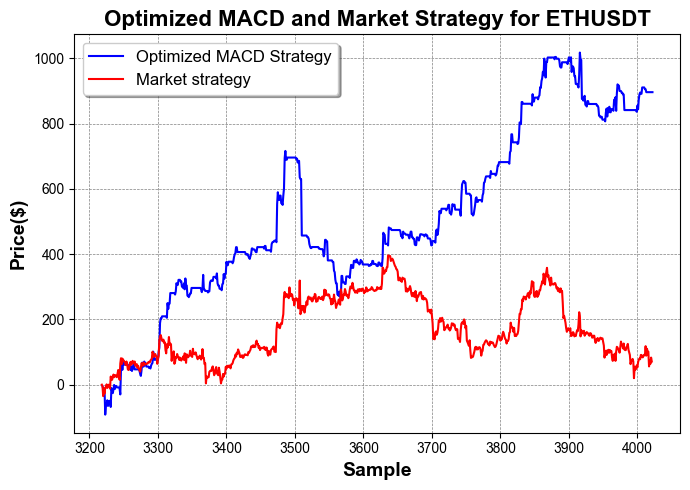

In [13]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

fig, axes = plt.subplots(1,1, figsize=(7,5))

axes.plot(tot_cum, color='blue', label='Optimized MACD Strategy')
axes.plot(trade_df['cumulative_market_return'], color='red', label='Market strategy')

axes.set_xlabel("Sample", fontsize=14, fontweight='bold')
axes.set_ylabel("Price($)", fontsize=14, fontweight='bold')
axes.set_title(f'Optimized MACD and Market Strategy for {STOCK}USDT', fontsize=16, fontweight='bold')

axes.grid(color='gray', linestyle='--', linewidth=0.5)  # Customize grid appearance
axes.legend(loc='best', fontsize=12, frameon=True, shadow=True, fancybox=True)

axes.spines['right'].set_visible(True)
axes.spines['bottom'].set_visible(True)
axes.spines['left'].set_visible(True)

plt.tight_layout()
plt.savefig(f'strategy/figs/MACD_MARKET_{STOCK}{TF}.png', dpi=300, bbox_inches='tight')
plt.show()

In [14]:
os.getcwd()

'c:\\Users\\arvin\\Documents\\Coding Project\\V4\\Algotrading_RL\\src'

# XLSTM

In [15]:
y_train_xlstm = np.load(f'data/xLSTM/{STOCK}/train_predictions.npy')
y_val_xlstm = np.load(f'data/xLSTM/{STOCK}/val_predictions.npy')
y_test_xlstm = np.load(f'data/xLSTM/{STOCK}/test_predictions.npy')

print(f'y_train_xlstm.shape is: {y_train_xlstm.shape}')
print(f'y_val_xlstm.shape is: {y_val_xlstm.shape}')
print(f'y_test_xlstm.shape is: {y_test_xlstm.shape}')

y_xlstm = np.vstack((y_train_xlstm, y_val_xlstm, y_test_xlstm))
print(f'y_xlstm.shape is: {y_xlstm.shape}')

y_train_xlstm.shape is: (4166, 48, 1)
y_val_xlstm.shape is: (595, 48, 1)
y_test_xlstm.shape is: (1191, 48, 1)
y_xlstm.shape is: (5952, 48, 1)


In [16]:
y_xlstm = y_xlstm[:,-1,:].squeeze()

In [17]:
y_xlstm.shape

(5952,)

In [18]:
if STOCK=='ETH':
    y_xlstm = y_xlstm[-4024:]


In [19]:
y_xlstm = y_xlstm[-805:]

In [20]:
y_xlstm.shape

(805,)

In [21]:
y_xlstm

array([2379.4714, 2354.736 , 2353.7214, 2339.7314, 2326.2432, 2344.221 ,
       2342.3042, 2348.3882, 2364.3867, 2353.4797, 2350.4102, 2355.034 ,
       2354.2722, 2365.754 , 2366.7537, 2374.4048, 2378.8298, 2380.7952,
       2380.6235, 2386.5178, 2380.315 , 2386.1936, 2381.36  , 2379.7563,
       2379.3123, 2385.3987, 2388.012 , 2380.7715, 2382.8303, 2410.9248,
       2432.865 , 2419.344 , 2427.237 , 2426.7756, 2422.5623, 2418.7095,
       2403.1191, 2419.4736, 2424.5781, 2401.288 , 2381.8958, 2401.637 ,
       2414.429 , 2410.6687, 2418.3804, 2419.258 , 2417.2861, 2422.8755,
       2415.8354, 2416.9548, 2411.7788, 2413.403 , 2410.6755, 2405.4512,
       2407.579 , 2397.044 , 2397.9333, 2389.0422, 2393.782 , 2405.0198,
       2422.4844, 2411.6345, 2410.6953, 2416.7979, 2414.0342, 2415.0771,
       2412.5115, 2415.23  , 2414.0964, 2418.4263, 2420.6284, 2418.6714,
       2422.9343, 2424.7773, 2429.1775, 2438.0684, 2450.8596, 2435.1477,
       2425.736 , 2443.2825, 2448.4749, 2427.645 , 

In [22]:
y_xlstm = np.roll(y_xlstm, -2)
y_xlstm

array([2353.7214, 2339.7314, 2326.2432, 2344.221 , 2342.3042, 2348.3882,
       2364.3867, 2353.4797, 2350.4102, 2355.034 , 2354.2722, 2365.754 ,
       2366.7537, 2374.4048, 2378.8298, 2380.7952, 2380.6235, 2386.5178,
       2380.315 , 2386.1936, 2381.36  , 2379.7563, 2379.3123, 2385.3987,
       2388.012 , 2380.7715, 2382.8303, 2410.9248, 2432.865 , 2419.344 ,
       2427.237 , 2426.7756, 2422.5623, 2418.7095, 2403.1191, 2419.4736,
       2424.5781, 2401.288 , 2381.8958, 2401.637 , 2414.429 , 2410.6687,
       2418.3804, 2419.258 , 2417.2861, 2422.8755, 2415.8354, 2416.9548,
       2411.7788, 2413.403 , 2410.6755, 2405.4512, 2407.579 , 2397.044 ,
       2397.9333, 2389.0422, 2393.782 , 2405.0198, 2422.4844, 2411.6345,
       2410.6953, 2416.7979, 2414.0342, 2415.0771, 2412.5115, 2415.23  ,
       2414.0964, 2418.4263, 2420.6284, 2418.6714, 2422.9343, 2424.7773,
       2429.1775, 2438.0684, 2450.8596, 2435.1477, 2425.736 , 2443.2825,
       2448.4749, 2427.645 , 2416.2053, 2419.7593, 

In [23]:
# y_xlstm = y_xlstm[1:]
y_xlstm

array([2353.7214, 2339.7314, 2326.2432, 2344.221 , 2342.3042, 2348.3882,
       2364.3867, 2353.4797, 2350.4102, 2355.034 , 2354.2722, 2365.754 ,
       2366.7537, 2374.4048, 2378.8298, 2380.7952, 2380.6235, 2386.5178,
       2380.315 , 2386.1936, 2381.36  , 2379.7563, 2379.3123, 2385.3987,
       2388.012 , 2380.7715, 2382.8303, 2410.9248, 2432.865 , 2419.344 ,
       2427.237 , 2426.7756, 2422.5623, 2418.7095, 2403.1191, 2419.4736,
       2424.5781, 2401.288 , 2381.8958, 2401.637 , 2414.429 , 2410.6687,
       2418.3804, 2419.258 , 2417.2861, 2422.8755, 2415.8354, 2416.9548,
       2411.7788, 2413.403 , 2410.6755, 2405.4512, 2407.579 , 2397.044 ,
       2397.9333, 2389.0422, 2393.782 , 2405.0198, 2422.4844, 2411.6345,
       2410.6953, 2416.7979, 2414.0342, 2415.0771, 2412.5115, 2415.23  ,
       2414.0964, 2418.4263, 2420.6284, 2418.6714, 2422.9343, 2424.7773,
       2429.1775, 2438.0684, 2450.8596, 2435.1477, 2425.736 , 2443.2825,
       2448.4749, 2427.645 , 2416.2053, 2419.7593, 

In [24]:
y_xlstm.shape

(805,)

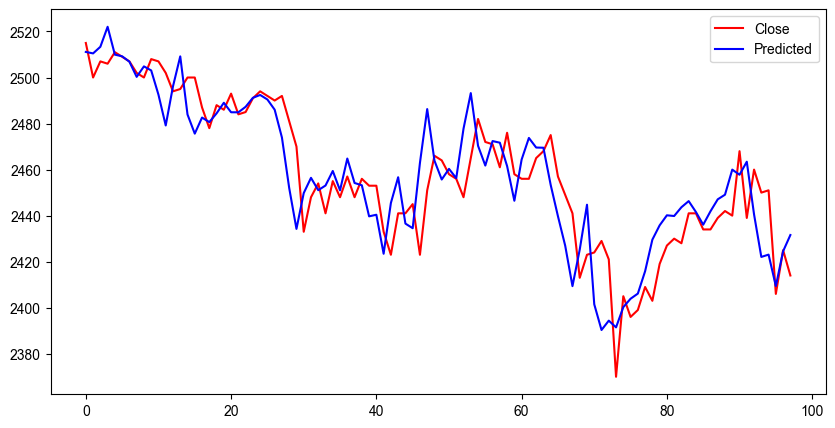

In [25]:
fig, ax = plt.subplots(1,1, figsize=(10,5))
ax.plot(trade_df['close'][-100:-2].to_numpy(), color='red', label='Close')
ax.plot(y_xlstm[-100:-2], color='blue', label='Predicted')
plt.legend()


## Modified backterster

In [26]:
import numpy as np
import pandas as pd

class Modified_MACDBacktester:
    def __init__(self, data, signal_price='smoothed_data', real_price='close',
                 sell_fee=0.115, buy_fee=0.115, initial_capital=100):
        """
        It works as a trade analyzer with a specific amount of money and trading cost.

        :param data: DataFrame containing different features.
        :param signal_price: For producing buy and sell signals (default: 'smoothed_data').
        :param real_price: For trading (default: 'close').
        :param sell_fee: Sell trading cost in percentage (default: 0.115).
        :param buy_fee: Buy trading cost in percentage (default: 0.115).
        :param initial_capital: Initial capital.
        """
        self.data = data.copy()
        self.signal_price = signal_price
        self.real_price = real_price
        self.sell_fee_percent = sell_fee / 100
        self.buy_fee_percent = buy_fee / 100
        self.initial_capital = initial_capital
        self.trades = []
        self.data['positions'] = 0

    def generate_signals(self):
        """
        Generates trading signals based on the MACD-XLSTM strategy.
        
        Buy signal (1) is generated when:
          - The 'macd_line' crosses above 'signal_line' (i.e. today's MACD > Signal and yesterday’s MACD ≤ Signal)
          - AND the XLSTM forecast is above the current close (y_xlstm > close)
        
        Sell signal (-1) is generated when:
          - The 'macd_line' crosses below 'signal_line' (i.e. today's MACD < Signal and yesterday’s MACD ≥ Signal)
          - AND the XLSTM forecast is below the current close (y_xlstm < close)
        
        After generating the raw signals, the method adjusts to ensure:
          - The first trade is not a sell.
          - If the final signal is a buy, it forces a sell at the end.
        
        Finally, it converts these raw signals into a binary positions indicator (1 for holding, 0 for not).
        """
        # Define buy and sell conditions
        buy_signals = (self.data['macd_line'] > self.data['signal_line']) & \
                      (self.data['macd_line'].shift(1) <= self.data['signal_line'].shift(1)) & \
                      (self.data['y_xlstm'] > self.data['close'])
        sell_signals = (self.data['macd_line'] < self.data['signal_line']) & \
                       (self.data['macd_line'].shift(1) >= self.data['signal_line'].shift(1)) & \
                       (self.data['y_xlstm'] < self.data['close'])
        
        # Initialize raw signals array: 1 for Buy, -1 for Sell, 0 for no action.
        raw_signals = np.zeros(len(self.data), dtype=np.int8)
        holding_position = False

        # Loop through each row to set signals based on the conditions and current holding state.
        for i in range(len(self.data)):
            if buy_signals.iloc[i] and not holding_position:
                raw_signals[i] = 1
                holding_position = True
            elif sell_signals.iloc[i] and holding_position:
                raw_signals[i] = -1
                holding_position = False

        # Adjust the signals:
        # 1. If the first nonzero signal is a sell, remove it.
        trade_idx = np.where(raw_signals != 0)[0]
        if len(trade_idx) > 0 and raw_signals[trade_idx[0]] == -1:
            raw_signals[trade_idx[0]] = 0

        # 2. If the last signal is a buy, force a sell at the end.
        if len(trade_idx) > 0 and raw_signals[trade_idx[-1]] == 1:
            raw_signals[-1] = -1

        # Save the raw signals in a dedicated column.
        self.data['signals_macd_xlstm'] = raw_signals

        # Convert raw signals to binary positions: 1 if in position, 0 if not.
        positions = np.zeros(len(self.data), dtype=np.int8)
        current_position = 0
        for i, signal in enumerate(raw_signals):
            if signal == 1:
                current_position = 1
            elif signal == -1:
                current_position = 0
            positions[i] = current_position
        self.data['positions'] = positions

        return self.data

    def backtest_strategy(self):
        """
        Backtests the strategy and calculates performance metrics.
        (Implementation remains unchanged.)
        """
        self.data['price'] = self.data[self.real_price]
        self.data['positions'] = self.data['positions'].astype(int)
        self.data['positions_diff'] = self.data['positions'].diff()
        self.data['positions_diff'].fillna(0)

        # Initialize cash and holdings
        self.data['cash'] = self.initial_capital
        self.data['holdings'] = 0.0
        self.data['total'] = self.initial_capital

        cash = self.initial_capital
        holdings = 0.0
        position = 0  # number of shares held
        buy_price = 0.0
        win_count = 0  
        total_trades = 0

        for idx, row in self.data.iterrows():
            position_change = row['positions_diff']
            price = row['price']
            if position_change == 1:  # Enter long position
                shares_to_buy = round(cash / price, 8)
                shares_to_buy *= (1 - self.buy_fee_percent)

                if shares_to_buy > 0.00002:
                    buy_price = round(cash / shares_to_buy, 8)
                    total_cost = round(shares_to_buy * buy_price, 8)
                    cash -= total_cost
                    holdings += shares_to_buy * price
                    position += shares_to_buy

            elif position_change == -1 and position > 0:  # Exit long position
                sell_price = price * (1 - self.sell_fee_percent)
                total_proceeds = position * sell_price
                cash += total_proceeds
                holdings -= position * sell_price
                trade_return = (sell_price - buy_price) / buy_price * 100
                self.trades.append(trade_return)
                position = 0
                total_trades += 1
                if trade_return > 0:
                    win_count += 1
            else:
                holdings = position * price

            total = cash + holdings
            self.data.at[idx, 'cash'] = float(cash)
            self.data.at[idx, 'holdings'] = holdings
            self.data.at[idx, 'total'] = float(total)

        if position > 0:
            price = self.data.iloc[-1]['price']
            sell_price = price * (1 - self.sell_fee_percent)
            total_proceeds = position * sell_price
            cash += total_proceeds
            trade_return = (sell_price - buy_price) / buy_price * 100
            self.trades.append(trade_return)
            position = 0
            total_trades += 1
            if trade_return > 0:
                win_count += 1
            total = cash + holdings
            self.data.at[self.data.index[-1], 'cash'] = cash
            self.data.at[self.data.index[-1], 'holdings'] = holdings
            self.data.at[self.data.index[-1], 'total'] = total

        self.results = self.data[['cash', 'holdings', 'total']]
        self.win_rate = (win_count / total_trades * 100) if total_trades > 0 else 0
        return self.data

    def get_performance_metrics(self):
        """
        Calculates and returns performance metrics.
        (Implementation remains unchanged.)
        """
        if not hasattr(self, 'results'):
            print("Please run backtest_strategy() before calculating performance metrics.")
            return None

        total_return = (self.results['total'].iloc[-1] - self.initial_capital) / self.initial_capital * 100
        returns = self.results['total'].pct_change().fillna(0)
        annualized_return = ((1 + returns.mean()) ** 365 - 1) * 100  # Assuming daily returns
        annualized_volatility = returns.std() * np.sqrt(365) * 100

        periods_per_year = 8760
        annual_rf_rate = 0.04  
        daily_rf_rate = annual_rf_rate / 365  
        hourly_rf_rate = daily_rf_rate / 24  

        excess_returns = returns - hourly_rf_rate
        mean_hourly_excess = excess_returns.mean()
        std_hourly = returns.std()  
        sharpe_ratio = (mean_hourly_excess / std_hourly) * np.sqrt(periods_per_year) if std_hourly != 0 else np.nan

        target_return = hourly_rf_rate  
        downside_returns = returns.copy()
        downside_returns[downside_returns > target_return] = 0
        std_downside = downside_returns.std()
        annualized_downside_deviation = std_downside * np.sqrt(periods_per_year)
        annualized_excess_return = mean_hourly_excess * periods_per_year
        sortino_ratio = annualized_excess_return / annualized_downside_deviation if annualized_downside_deviation != 0 else np.nan

        max_drawdown = ((self.results['total'].cummax() - self.results['total']) / self.results['total'].cummax()).max() * 100

        metrics = {
            'Total Return (%)': total_return,
            'Annualized Return (%)': annualized_return,
            'Annualized Volatility (%)': annualized_volatility,
            'Sharpe Ratio': sharpe_ratio,
            'Sortino Ratio': sortino_ratio,
            'Max Drawdown (%)': max_drawdown,
            'Win Rate (%)': self.win_rate
        }
        return metrics, self.results

    def print_trades(self):
        """
        Prints individual trade returns.
        """
        if not self.trades:
            print("No trades have been executed.")
            return
        for idx, trade_return in enumerate(self.trades, 1):
            print(f"Trade {idx}: Return = {trade_return:.2f}%")
        total_return = sum(self.trades)
        print(f"Total Return from trades: {total_return:.2f}%")


In [27]:
df_all.columns

Index(['open', 'high', 'low', 'close', 'volume', 'smoothed_data', 'macd_line',
       'signal_line', 'histo'],
      dtype='object')

In [28]:
df_all = df_all.iloc[-805:,:]

In [29]:
df_all = df_all.reset_index(drop=True)

In [30]:
df_all.loc[:,'y_xlstm'] = y_xlstm

In [31]:
backtester = Modified_MACDBacktester(df_all, signal_price='close', real_price='close',initial_capital=df_all['close'][0])
backtester.generate_signals()
backtester.backtest_strategy()
metrics, results = backtester.get_performance_metrics()
print(metrics)
backtester.print_trades()

{'Total Return (%)': 46.85386168400999, 'Annualized Return (%)': 19.43845052884101, 'Annualized Volatility (%)': 8.252485774157261, 'Sharpe Ratio': 10.448456840348664, 'Sortino Ratio': 17.871349627764424, 'Max Drawdown (%)': 4.512489927470947, 'Win Rate (%)': 80.64516129032258}
Trade 1: Return = 3.53%
Trade 2: Return = 0.60%
Trade 3: Return = 3.41%
Trade 4: Return = 0.26%
Trade 5: Return = -0.31%
Trade 6: Return = 4.47%
Trade 7: Return = 7.02%
Trade 8: Return = 0.15%
Trade 9: Return = 0.92%
Trade 10: Return = 0.45%
Trade 11: Return = 1.18%
Trade 12: Return = 0.15%
Trade 13: Return = 0.11%
Trade 14: Return = 1.77%
Trade 15: Return = 1.02%
Trade 16: Return = 0.19%
Trade 17: Return = -0.27%
Trade 18: Return = -0.19%
Trade 19: Return = 1.45%
Trade 20: Return = 1.93%
Trade 21: Return = 1.90%
Trade 22: Return = 0.09%
Trade 23: Return = 1.02%
Trade 24: Return = 1.54%
Trade 25: Return = 4.03%
Trade 26: Return = 1.10%
Trade 27: Return = 1.14%
Trade 28: Return = -0.43%
Trade 29: Return = -0.19%


C:\Users\arvin\AppData\Local\Temp\ipykernel_17780\2289309262.py:144: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2347.2974954252672' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  self.data.at[idx, 'total'] = float(total)
C:\Users\arvin\AppData\Local\Temp\ipykernel_17780\2289309262.py:142: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2432.8464493666434' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  self.data.at[idx, 'cash'] = float(cash)


In [32]:
tot_xlstm = results['total'].diff()
tot_cum_xlstm = tot_xlstm.cumsum()

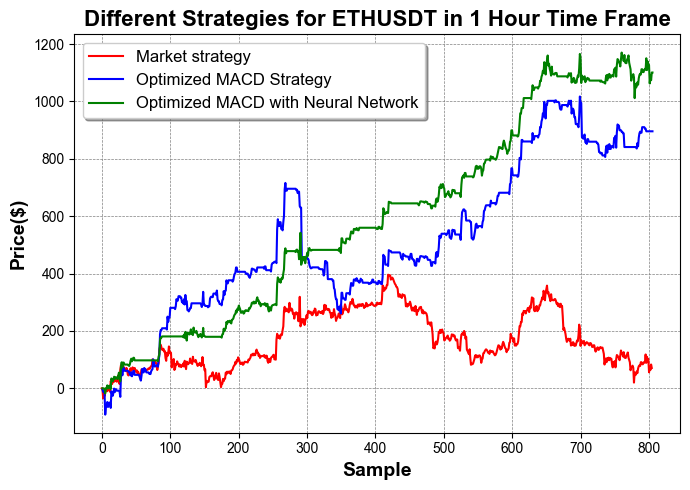

In [33]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

fig, axes = plt.subplots(1,1, figsize=(7,5))

t = np.linspace(start=0, stop=len(tot_cum), num=len(tot_cum))

axes.plot(t,trade_df['cumulative_market_return'], color='red', label='Market strategy')
axes.plot(t,tot_cum, color='blue', label='Optimized MACD Strategy')
axes.plot(t,tot_cum_xlstm, color = 'green', label = 'Optimized MACD with Neural Network')

axes.set_xlabel("Sample", fontsize=14, fontweight='bold')
axes.set_ylabel("Price($)", fontsize=14, fontweight='bold')
axes.set_title(f'Different Strategies for {STOCK}USDT in 1 Hour Time Frame', fontsize=16, fontweight='bold')

axes.grid(color='gray', linestyle='--', linewidth=0.5)  # Customize grid appearance
axes.legend(loc='best', fontsize=12, frameon=True, shadow=True, fancybox=True)

axes.spines['right'].set_visible(True)
axes.spines['bottom'].set_visible(True)
axes.spines['left'].set_visible(True)

plt.tight_layout()
plt.savefig(f'strategy/figs/xLSTM_MACD_MARKET_{STOCK}{TF}.png', dpi=300, bbox_inches='tight')
plt.show()